- ## Imports 

In [4]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torchvision import datasets, transforms
# import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm
from torchvision import datasets, transforms



- ## Data Preprocessing 

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# ---------------- TRANSFORM ----------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) # here 0.1307 is mean and 0.3081 is stddev of MNIST dataset
])

# ---------------- FULL TRAIN DATASET ----------------
full_train_dataset = datasets.MNIST(
    './data',
    train=True,
    download=True,
    transform=transform
)

# ---------------- TRAIN / VAL SPLIT ----------------
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size]
)

# ---------------- DATALOADERS ----------------
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    datasets.MNIST(
        './data',
        train=False,
        download=True,
        transform=transform
    ),
    batch_size=1000,
    shuffle=False
)


- ## CNN model Implementation 

In [1]:
# # Batch Normalization 
# Har layer ke output ko normalize karna
# (mean ≈ 0, variance ≈ 1)

In [ ]:
class CNN_Model(nn.Module):
    def __init__(self):
        super(CNN_Model, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, 3) # here 1 is input channel for grayscale imageand 32 is output channel
        self.conv2 = nn.Conv2d(32, 64, 3)# 32 is input channel and 64 is output channel
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.25)

        self.fc1 = nn.Linear(64 * 12 * 12, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = self.pool(x)
        x = self.dropout(x)

        x = x.view(-1, 64 * 12 * 12) # here view is used to flatten the tensor
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)

        return x


- ## MLP model Implementation 

In [ ]:
class MLP_Model(nn.Module):
    def __init__(self):
        super(MLP_Model, self).__init__()

        self.fc1 = nn.Linear(784, 256)
        self.bn1 = nn.BatchNorm1d(256)

        self.fc2 = nn.Linear(256, 128) # here 256 is input features and 128 is output features and we are adding BatchNorm layer after this fc layer
        self.bn2 = nn.BatchNorm1d(128) #here 128 is number of features for BatchNorm layer   

        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 784)
        x = torch.relu(self.bn1(self.fc1(x)))
        x = torch.relu(self.bn2(self.fc2(x)))
        x = self.fc3(x)
        return x



'''Input (784)
   ↓
FC Layer (256) + BatchNorm + ReLU
   ↓
FC Layer (128) + BatchNorm + ReLU
   ↓
FC Layer (10)
'''

'Input (784)\n   ↓\nFC Layer (256) + BatchNorm + ReLU\n   ↓\nFC Layer (128) + BatchNorm + ReLU\n   ↓\nFC Layer (10)\n'

- ## Training and Evaluation functions 

In [ ]:
def train(model, optimizer, criterion,
          train_loader, val_loader,
          epochs=10, device='cpu'): # Here Criterion is loss function 

    model.to(device)

    train_losses = []
    val_losses = []

    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        # -------- TRAINING --------
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        progress_bar = tqdm(
            train_loader,
            desc=f"Epoch [{epoch+1}/{epochs}]"
        )

        for images, labels in progress_bar:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            progress_bar.set_postfix(
                train_acc=100 * correct / total,
                train_loss=loss.item()
            )

        epoch_train_loss = running_loss / len(train_loader)
        epoch_train_acc = 100 * correct / total

        # -------- VALIDATION --------
        model.eval()

        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / len(val_loader)
        epoch_val_acc = 100 * val_correct / val_total

        # -------- STORE HISTORY --------
        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)

        train_accuracies.append(epoch_train_acc)
        val_accuracies.append(epoch_val_acc)

        print(
            f"Epoch {epoch+1}: "
            f"Train Loss={epoch_train_loss:.4f}, "
            f"Train Acc={epoch_train_acc:.2f}% | "
            f"Val Loss={epoch_val_loss:.4f}, "
            f"Val Acc={epoch_val_acc:.2f}%"
        )

    return train_losses, val_losses, train_accuracies, val_accuracies


- ### Testing Function

In [ ]:



def test(model, test_loader, device='cpu'):
    model.to(device)
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")
    return accuracy




In [11]:
def plot_curves(train_losses, val_losses,
                train_accuracies, val_accuracies):

    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    # -------- LOSS --------
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label="Train Loss", marker='o')
    plt.plot(epochs, val_losses, label="Val Loss", marker='o')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Train vs Validation Loss")
    plt.legend()
    plt.grid(True)

    # -------- ACCURACY --------
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, label="Train Accuracy", marker='o')
    plt.plot(epochs, val_accuracies, label="Val Accuracy", marker='o')
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy (%)")
    plt.title("Train vs Validation Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


Epoch [1/10]: 100%|██████████| 750/750 [00:11<00:00, 67.80it/s, train_acc=95.6, train_loss=0.045]  


Epoch 1: Train Loss=0.1450, Train Acc=95.59% | Val Loss=0.0876, Val Acc=97.28%


Epoch [2/10]: 100%|██████████| 750/750 [00:12<00:00, 62.41it/s, train_acc=98.6, train_loss=0.0455]  


Epoch 2: Train Loss=0.0461, Train Acc=98.57% | Val Loss=0.0441, Val Acc=98.72%


Epoch [3/10]: 100%|██████████| 750/750 [00:12<00:00, 61.90it/s, train_acc=99, train_loss=0.0574]    


...

Epoch 8: Train Loss=0.0105, Train Acc=99.63% | Val Loss=0.0502, Val Acc=98.70%


Epoch [9/10]: 100%|██████████| 750/750 [00:11<00:00, 62.81it/s, train_acc=99.8, train_loss=0.000282]


Epoch 9: Train Loss=0.0077, Train Acc=99.75% | Val Loss=0.0558, Val Acc=98.63%


Epoch [10/10]: 100%|██████████| 750/750 [00:12<00:00, 62.24it/s, train_acc=99.7, train_loss=0.0094]  


Epoch 10: Train Loss=0.0081, Train Acc=99.72% | Val Loss=0.0487, Val Acc=98.88%


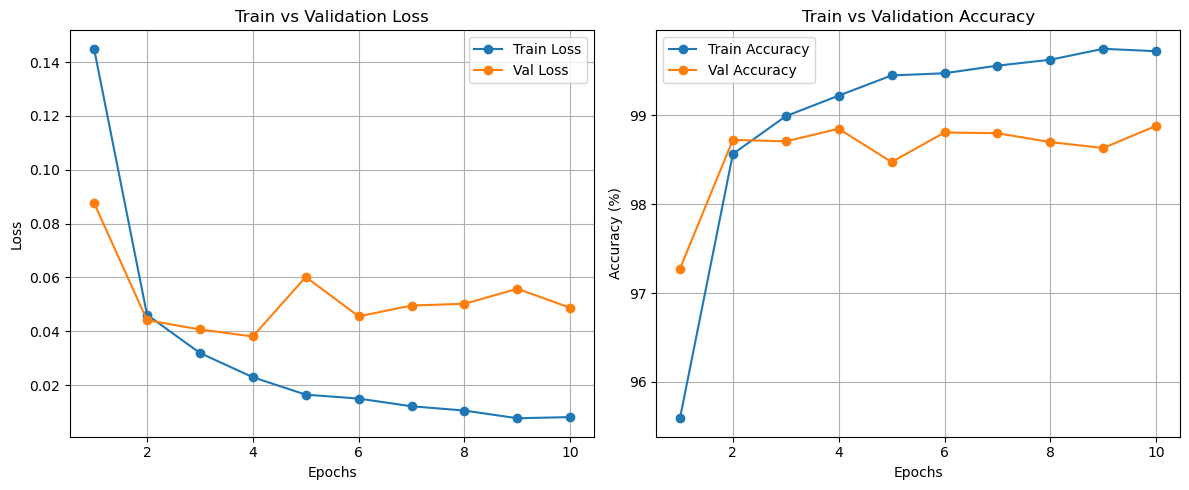

In [12]:
import torch.nn as nn
import torch.optim as optim

# ---------------- DEVICE ----------------
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# ---------------- MODEL / LOSS / OPTIMIZER ----------------
model = CNN_Model().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ---------------- TRAIN ----------------
train_losses, val_losses, train_acc, val_acc = train(
    model,
    optimizer,
    criterion,
    train_loader,
    val_loader,
    epochs=10,
    device=device
)

# ---------------- PLOTS ----------------
plot_curves(train_losses, val_losses, train_acc, val_acc)


- ## MLP-1 Architecture (512–256–128) — 

In [21]:
import torch
import torch.nn as nn

class MLP_1(nn.Module):
    def __init__(self):
        super(MLP_1, self).__init__()

        self.fc1 = nn.Linear(784, 512)
        self.bn1 = nn.BatchNorm1d(512)

        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)

        self.fc3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128)

        self.fc4 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)     # Flatten
        x = torch.relu(self.bn1(self.fc1(x)))
        x = torch.relu(self.bn2(self.fc2(x)))
        x = torch.relu(self.bn3(self.fc3(x)))
        x = self.fc4(x)
        return x


- ## MLP-2 Architecture (256) — 

In [22]:
class MLP_2(nn.Module):
    def __init__(self):
        super(MLP_2, self).__init__()

        self.fc1 = nn.Linear(784, 256)
        self.bn1 = nn.BatchNorm1d(256)

        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)     # Flatten
        x = torch.relu(self.bn1(self.fc1(x)))
        x = self.fc2(x)
        return x


- ## Training Function

In [23]:
def train_model(model, optimizer, criterion,
                train_loader, val_loader,
                epochs, device):

    model.to(device)

    for epoch in range(epochs):
        model.train()
        correct = 0
        total = 0
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_acc = 100 * correct / total

        # -------- Validation --------
        model.eval()
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_acc = 100 * val_correct / val_total

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Acc: {train_acc:.2f}% | "
            f"Val Acc: {val_acc:.2f}%"
        )

    return val_acc


- ## Experiments with MLP to fill the Table 

In [24]:
import torch.optim as optim

device = 'cuda' if torch.cuda.is_available() else 'cpu'
criterion = nn.CrossEntropyLoss()

# -------- MLP-1 (SGD, 20 epochs) --------
mlp1 = MLP_1()
optimizer1 = optim.SGD(mlp1.parameters(), lr=0.01, momentum=0.9)

mlp1_acc = train_model(
    mlp1,
    optimizer1,
    criterion,
    train_loader,
    val_loader,
    epochs=20,
    device=device
)

print(f"Final Validation Accuracy (MLP-1): {mlp1_acc:.2f}%")

# -------- MLP-2 (Adam, 15 epochs) --------
mlp2 = MLP_2()
optimizer2 = optim.Adam(mlp2.parameters(), lr=0.001)

mlp2_acc = train_model(
    mlp2,
    optimizer2,
    criterion,
    train_loader,
    val_loader,
    epochs=15,
    device=device
)

print(f"Final Validation Accuracy (MLP-2): {mlp2_acc:.2f}%")


Epoch [1/20] | Train Acc: 93.56% | Val Acc: 97.21%
Epoch [2/20] | Train Acc: 97.48% | Val Acc: 97.68%
Epoch [3/20] | Train Acc: 98.39% | Val Acc: 97.97%
Epoch [4/20] | Train Acc: 98.86% | Val Acc: 97.97%
Epoch [5/20] | Train Acc: 99.11% | Val Acc: 97.99%
Epoch [6/20] | Train Acc: 99.36% | Val Acc: 98.28%
Epoch [7/20] | Train Acc: 99.51% | Val Acc: 98.39%
Epoch [8/20] | Train Acc: 99.60% | Val Acc: 98.35%
Epoch [9/20] | Train Acc: 99.71% | Val Acc: 98.33%
Epoch [10/20] | Train Acc: 99.70% | Val Acc: 98.32%
Epoch [11/20] | Train Acc: 99.71% | Val Acc: 98.37%
Epoch [12/20] | Train Acc: 99.82% | Val Acc: 98.42%
Epoch [13/20] | Train Acc: 99.80% | Val Acc: 98.51%
Epoch [14/20] | Train Acc: 99.85% | Val Acc: 98.39%
Epoch [15/20] | Train Acc: 99.88% | Val Acc: 98.45%
Epoch [16/20] | Train Acc: 99.88% | Val Acc: 98.47%
Epoch [17/20] | Train Acc: 99.92% | Val Acc: 98.46%
Epoch [18/20] | Train Acc: 99.95% | Val Acc: 98.35%
Epoch [19/20] | Train Acc: 99.94% | Val Acc: 98.55%
Epoch [20/20] | Train

- # Flexible MLP with Batch Normalization for the Tasks 

In [26]:
class FlexibleMLP(nn.Module):
    def __init__(self, activation='relu', use_bn=True, dropout=0.0):
        super().__init__()

        self.fc1 = nn.Linear(784, 256)
        self.bn1 = nn.BatchNorm1d(256) if use_bn else nn.Identity()
        self.drop1 = nn.Dropout(dropout)

        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128) if use_bn else nn.Identity()
        self.drop2 = nn.Dropout(dropout)

        self.fc3 = nn.Linear(128, 10)

        if activation == 'relu':
            self.act = nn.ReLU()
        elif activation == 'sigmoid':
            self.act = nn.Sigmoid()
        elif activation == 'tanh':
            self.act = nn.Tanh()
        else:
            raise ValueError("Invalid activation")

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.drop1(self.act(self.bn1(self.fc1(x))))
        x = self.drop2(self.act(self.bn2(self.fc2(x))))
        x = self.fc3(x)
        return x


- # Common Training + Evaluation Function

In [32]:
# def run_experiment(model, optimizer, epochs):
#     criterion = nn.CrossEntropyLoss()
#     model.to(device)

#     train_losses = []
#     val_losses = []

#     for epoch in range(epochs):
#         model.train()
#         total_loss = 0.0

#         for x, y in train_loader:
#             x, y = x.to(device), y.to(device)
#             optimizer.zero_grad()
#             out = model(x)
#             loss = criterion(out, y)
#             loss.backward()
#             optimizer.step()
#             total_loss += loss.item()

#         train_losses.append(total_loss / len(train_loader))

#         # validation loss
#         model.eval()
#         val_loss = 0.0
#         with torch.no_grad():
#             for x, y in val_loader:
#                 x, y = x.to(device), y.to(device)
#                 val_loss += criterion(model(x), y).item()

#         val_losses.append(val_loss / len(val_loader))

#         print(f"Epoch {epoch+1}/{epochs} | "
#               f"Train Loss={train_losses[-1]:.4f} | "
#               f"Val Loss={val_losses[-1]:.4f}")

#     # test accuracy
#     correct, total = 0, 0
#     with torch.no_grad():
#         for x, y in test_loader:
#             x, y = x.to(device), y.to(device)
#             pred = model(x).argmax(dim=1)
#             correct += (pred == y).sum().item()
#             total += y.size(0)

#     test_acc = 100 * correct / total
#     return train_losses, val_losses, test_acc

from tqdm import tqdm
import torch
import torch.nn as nn

def train_with_metrics(model, optimizer, criterion,
                       train_loader, val_loader,
                       epochs, device):

    model.to(device)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        # -------- TRAINING --------
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        pbar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]")

        for x, y in pbar:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == y).sum().item()
            total += y.size(0)

            pbar.set_postfix(
                train_loss=loss.item(),
                train_acc=100 * correct / total
            )

        epoch_train_loss = running_loss / len(train_loader)
        epoch_train_acc = 100 * correct / total

        # -------- VALIDATION --------
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                outputs = model(x)
                loss = criterion(outputs, y)

                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == y).sum().item()
                val_total += y.size(0)

        epoch_val_loss = val_loss / len(val_loader)
        epoch_val_acc = 100 * val_correct / val_total

        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
        train_accs.append(epoch_train_acc)
        val_accs.append(epoch_val_acc)

        print(
            f"Epoch {epoch+1}: "
            f"Train Loss={epoch_train_loss:.4f}, "
            f"Train Acc={epoch_train_acc:.2f}% | "
            f"Val Loss={epoch_val_loss:.4f}, "
            f"Val Acc={epoch_val_acc:.2f}%"
        )

    return train_losses, val_losses, train_accs, val_accs



- # ONE PLOT FUNCTION (USED FOR ALL TASKS)

In [33]:
import matplotlib.pyplot as plt

def plot_task_curves(train_losses, val_losses,
                     train_accs, val_accs,
                     title_prefix):

    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    # ---- LOSS ----
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, val_losses, label="Val Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} - Loss")
    plt.legend()
    plt.grid(True)

    # ---- ACCURACY ----
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accs, label="Train Acc")
    plt.plot(epochs, val_accs, label="Val Acc")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy (%)")
    plt.title(f"{title_prefix} - Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


- # TASK-1: ACTIVATION FUNCTION (Sigmoid / Tanh / ReLU)

- tanh is a smooth, zero-centered activation function that squashes inputs between −1 and +1, providing better gradient flow than sigmoid but still suffering from vanishing gradients in deep networks.


=== Task-1 | Activation: sigmoid ===


Epoch [1/10]: 100%|██████████| 750/750 [00:09<00:00, 78.33it/s, train_acc=78.8, train_loss=0.93] 


Epoch 1: Train Loss=1.2878, Train Acc=78.82% | Val Loss=0.8448, Val Acc=88.08%


Epoch [2/10]: 100%|██████████| 750/750 [00:09<00:00, 79.05it/s, train_acc=88.1, train_loss=0.745]


Epoch 2: Train Loss=0.7064, Train Acc=88.06% | Val Loss=0.5760, Val Acc=90.09%


...

Epoch 8: Train Loss=0.3151, Train Acc=92.27% | Val Loss=0.2983, Val Acc=92.57%


Epoch [9/10]: 100%|██████████| 750/750 [00:10<00:00, 74.80it/s, train_acc=92.6, train_loss=0.269]


Epoch 9: Train Loss=0.2951, Train Acc=92.64% | Val Loss=0.2805, Val Acc=92.89%


Epoch [10/10]: 100%|██████████| 750/750 [00:09<00:00, 81.23it/s, train_acc=93.2, train_loss=0.31] 


Epoch 10: Train Loss=0.2732, Train Acc=93.17% | Val Loss=0.2616, Val Acc=93.21%


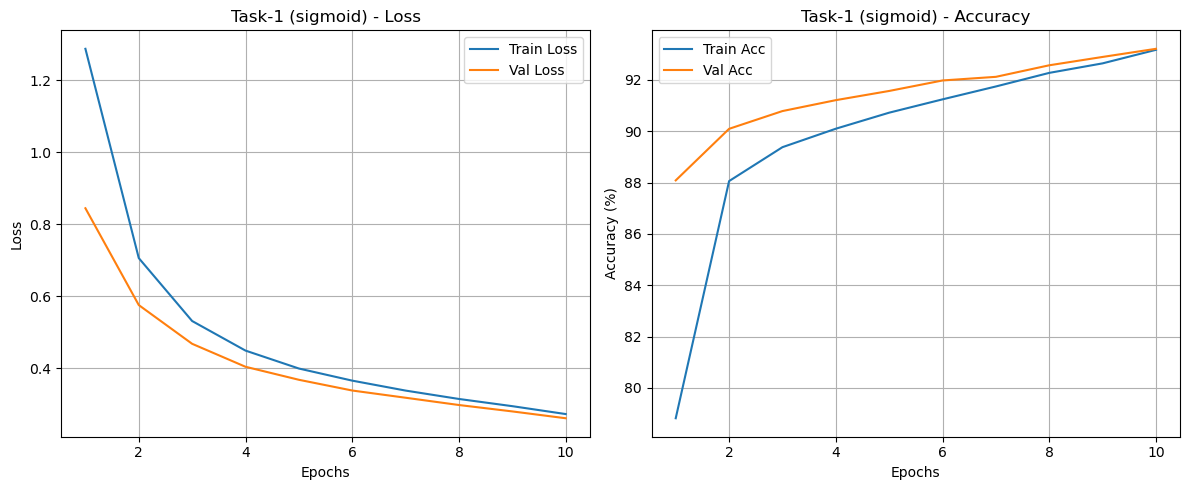


=== Task-1 | Activation: tanh ===


Epoch [1/10]: 100%|██████████| 750/750 [00:09<00:00, 80.32it/s, train_acc=87, train_loss=0.481]  


Epoch 1: Train Loss=0.5365, Train Acc=86.96% | Val Loss=0.3132, Val Acc=91.80%


Epoch [2/10]: 100%|██████████| 750/750 [00:09<00:00, 81.91it/s, train_acc=91.9, train_loss=0.23]  


Epoch 2: Train Loss=0.2948, Train Acc=91.92% | Val Loss=0.2440, Val Acc=93.33%


...

Epoch 8: Train Loss=0.1025, Train Acc=97.26% | Val Loss=0.1201, Val Acc=96.53%


Epoch [9/10]: 100%|██████████| 750/750 [00:09<00:00, 78.56it/s, train_acc=97.6, train_loss=0.103] 


Epoch 9: Train Loss=0.0895, Train Acc=97.63% | Val Loss=0.1126, Val Acc=96.62%


Epoch [10/10]: 100%|██████████| 750/750 [00:09<00:00, 81.25it/s, train_acc=98, train_loss=0.055]   


Epoch 10: Train Loss=0.0781, Train Acc=97.97% | Val Loss=0.1100, Val Acc=96.82%


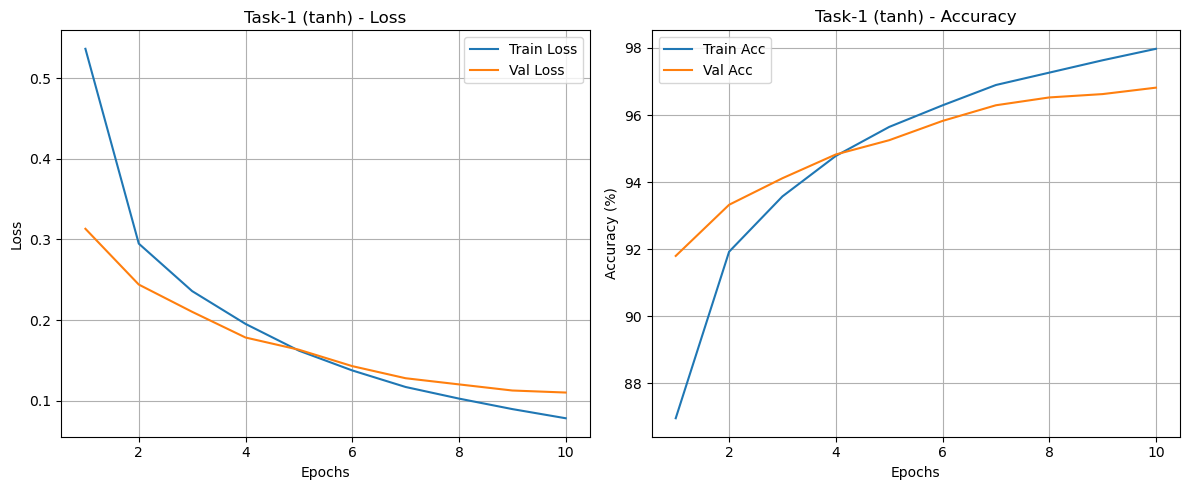


=== Task-1 | Activation: relu ===


Epoch [1/10]: 100%|██████████| 750/750 [00:09<00:00, 82.35it/s, train_acc=88.1, train_loss=0.257]


Epoch 1: Train Loss=0.5325, Train Acc=88.09% | Val Loss=0.2335, Val Acc=94.11%


Epoch [2/10]: 100%|██████████| 750/750 [00:09<00:00, 82.25it/s, train_acc=94.6, train_loss=0.22]  


Epoch 2: Train Loss=0.2102, Train Acc=94.59% | Val Loss=0.1612, Val Acc=95.61%


...

Epoch 8: Train Loss=0.0581, Train Acc=98.55% | Val Loss=0.0825, Val Acc=97.69%


Epoch [9/10]: 100%|██████████| 750/750 [00:09<00:00, 80.99it/s, train_acc=98.8, train_loss=0.0579] 


Epoch 9: Train Loss=0.0503, Train Acc=98.81% | Val Loss=0.0783, Val Acc=97.74%


Epoch [10/10]: 100%|██████████| 750/750 [00:09<00:00, 80.76it/s, train_acc=98.9, train_loss=0.0376] 


Epoch 10: Train Loss=0.0444, Train Acc=98.93% | Val Loss=0.0755, Val Acc=97.80%


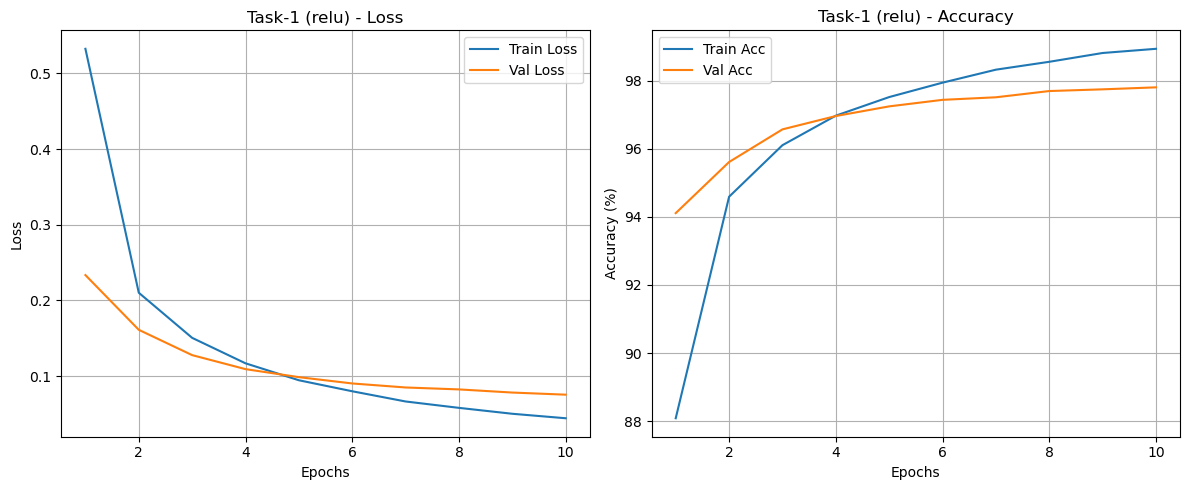

In [34]:
task1_results = {}

for act in ['sigmoid', 'tanh', 'relu']:
    print(f"\n=== Task-1 | Activation: {act} ===")

    model = FlexibleMLP(activation=act)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss()

    tl, vl, ta, va = train_with_metrics(
        model, optimizer, criterion,
        train_loader, val_loader,
        epochs=10,
        device=device
    )

    task1_results[act] = (tl, vl, ta, va)

    plot_task_curves(tl, vl, ta, va,
                     title_prefix=f"Task-1 ({act})")


### Task 1: Activation Function Comparison –  Summary

| Experiment | Activation Function | Convergence Speed | Training Loss Behavior | Accuracy Trend | Gradient Behavior | Key Observation |
|-----------|---------------------|-------------------|------------------------|----------------|-------------------|-----------------|
| 1 | Sigmoid | Slow | Gradual decrease | Slow improvement | Vanishing gradients | Suffers from slow learning and saturation |
| 2 | Tanh | Moderate | Smoother than sigmoid | Faster than sigmoid | Reduced vanishing | Zero-centered, but still saturates |
| 3 | ReLU | Fast | Sharp early decrease | Rapid improvement | Stable gradients | Fastest convergence and best performance |


- ###### ReLU outperforms sigmoid and tanh in terms of convergence speed and accuracy, while sigmoid suffers the most from vanishing gradients.

- ###### 3- ReLU leads to significantly faster convergence and higher accuracy due to non-saturating gradients, making it the preferred activation function for deep networks.

- ###### 2- Tanh performs better than sigmoid due to its zero-centered nature, resulting in faster convergence, though it still experiences gradient saturation for large input values.

- ###### 1 - The sigmoid activation exhibits slow convergence and reduced learning speed due to vanishing gradients, especially during the early stages of training.

- # TASK-2: OPTIMIZER COMPARISON


=== Task-2 | Optimizer: SGD ===


Epoch [1/10]: 100%|██████████| 750/750 [00:09<00:00, 80.51it/s, train_acc=68.4, train_loss=0.879]


Epoch 1: Train Loss=1.3777, Train Acc=68.39% | Val Loss=0.9031, Val Acc=84.15%


Epoch [2/10]: 100%|██████████| 750/750 [00:09<00:00, 81.18it/s, train_acc=85.8, train_loss=0.737]


Epoch 2: Train Loss=0.7583, Train Acc=85.75% | Val Loss=0.6081, Val Acc=89.17%


...

Epoch 8: Train Loss=0.2951, Train Acc=92.86% | Val Loss=0.2625, Val Acc=93.63%


Epoch [9/10]: 100%|██████████| 750/750 [00:09<00:00, 80.81it/s, train_acc=93.3, train_loss=0.257]


Epoch 9: Train Loss=0.2752, Train Acc=93.34% | Val Loss=0.2453, Val Acc=93.89%


Epoch [10/10]: 100%|██████████| 750/750 [00:09<00:00, 80.44it/s, train_acc=93.6, train_loss=0.378] 


Epoch 10: Train Loss=0.2585, Train Acc=93.64% | Val Loss=0.2307, Val Acc=94.29%


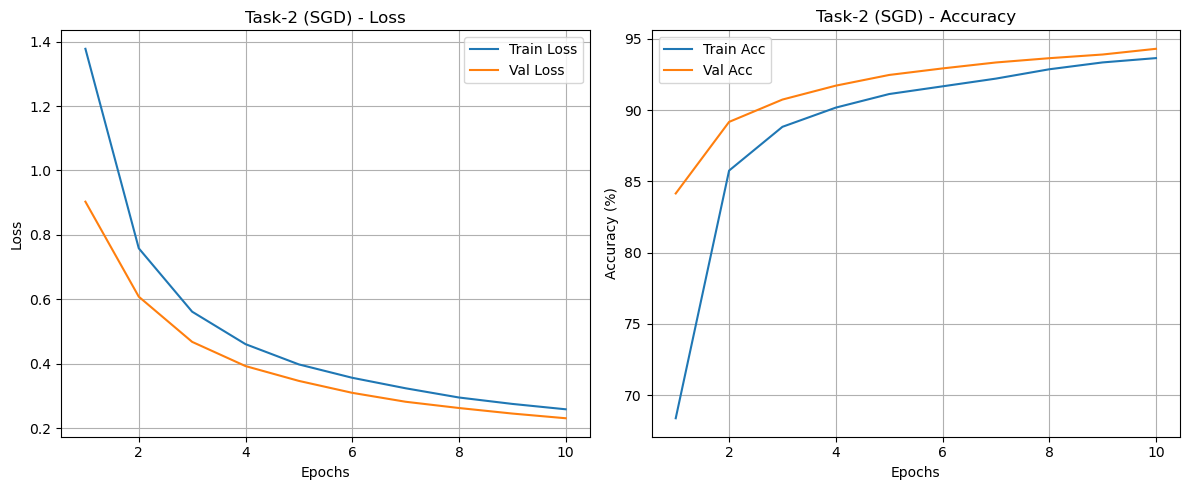


=== Task-2 | Optimizer: SGD+Momentum ===


Epoch [1/10]: 100%|██████████| 750/750 [00:09<00:00, 76.13it/s, train_acc=93, train_loss=0.265]   


Epoch 1: Train Loss=0.2400, Train Acc=93.03% | Val Loss=0.1103, Val Acc=96.97%


Epoch [2/10]: 100%|██████████| 750/750 [00:09<00:00, 79.14it/s, train_acc=97.2, train_loss=0.0302] 


Epoch 2: Train Loss=0.0927, Train Acc=97.21% | Val Loss=0.0866, Val Acc=97.28%


...

Epoch 8: Train Loss=0.0197, Train Acc=99.42% | Val Loss=0.0699, Val Acc=98.20%


Epoch [9/10]: 100%|██████████| 750/750 [00:09<00:00, 78.12it/s, train_acc=99.6, train_loss=0.0216]  


Epoch 9: Train Loss=0.0146, Train Acc=99.59% | Val Loss=0.0737, Val Acc=97.93%


Epoch [10/10]: 100%|██████████| 750/750 [00:09<00:00, 79.44it/s, train_acc=99.6, train_loss=0.00148] 


Epoch 10: Train Loss=0.0131, Train Acc=99.62% | Val Loss=0.0700, Val Acc=98.08%


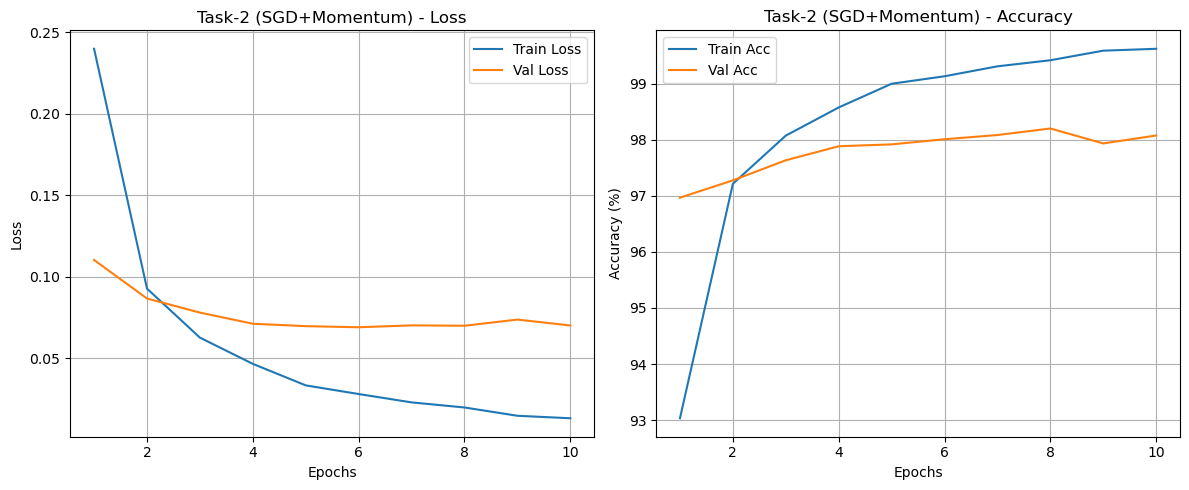


=== Task-2 | Optimizer: Adam ===


Epoch [1/10]: 100%|██████████| 750/750 [00:10<00:00, 73.88it/s, train_acc=93.6, train_loss=0.1]   


Epoch 1: Train Loss=0.2303, Train Acc=93.63% | Val Loss=0.1018, Val Acc=96.96%


Epoch [2/10]: 100%|██████████| 750/750 [00:10<00:00, 71.60it/s, train_acc=97.2, train_loss=0.113]  


Epoch 2: Train Loss=0.0893, Train Acc=97.21% | Val Loss=0.0878, Val Acc=97.27%


...

Epoch 8: Train Loss=0.0225, Train Acc=99.25% | Val Loss=0.0738, Val Acc=97.90%


Epoch [9/10]: 100%|██████████| 750/750 [00:10<00:00, 72.50it/s, train_acc=99.4, train_loss=0.0268]  


Epoch 9: Train Loss=0.0199, Train Acc=99.37% | Val Loss=0.0811, Val Acc=97.78%


Epoch [10/10]: 100%|██████████| 750/750 [00:10<00:00, 73.85it/s, train_acc=99.3, train_loss=0.0887]  


Epoch 10: Train Loss=0.0187, Train Acc=99.31% | Val Loss=0.0750, Val Acc=97.99%


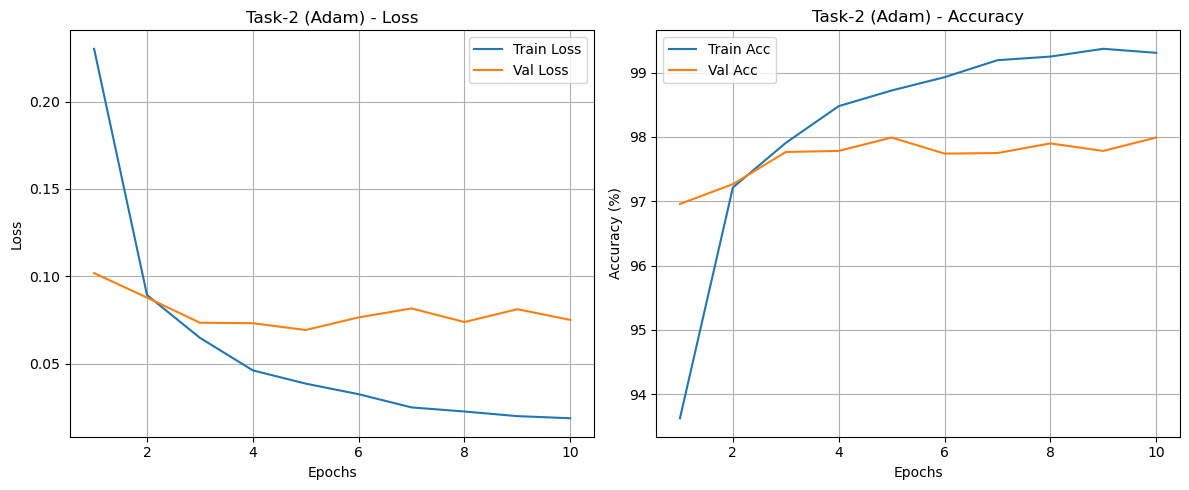

In [ ]:
task2_results = {}

optimizers = {
    'SGD': torch.optim.SGD,
    'SGD+Momentum': lambda p: torch.optim.SGD(p, lr=0.01, momentum=0.9),
    'Adam': torch.optim.Adam
}

for name, opt_fn in optimizers.items():
    print(f"\n=== Task-2 | Optimizer: {name} ===")

    model = FlexibleMLP(activation='relu')
    optimizer = opt_fn(model.parameters())
    criterion = nn.CrossEntropyLoss()

    tl, vl, ta, va = train_with_metrics(
        model, optimizer, criterion,
        train_loader, val_loader,
        epochs=10,
        device=device
    )

    task2_results[name] = (tl, vl, ta, va)

    plot_task_curves(tl*, vl, ta, va,
                     title_prefix=f"Task-2 ({name})")


### Task 2: Optimizer Comparison – Tabular Summary (Activation Fixed: ReLU)

| Experiment | Optimizer | Convergence Speed | Loss Curve Stability | Accuracy Growth | Sensitivity to LR | Key Observation |
|-----------|-----------|-------------------|----------------------|-----------------|------------------|-----------------|
| 1 | SGD | Slow | Noisy | Gradual | High | Slow convergence and oscillations |
| 2 | SGD + Momentum | Moderate | Smoother | Steady | Medium | Momentum reduces oscillations |
| 3 | Adam | Fast | Very Stable | Rapid | Low | Fastest convergence with adaptive learning |


- # TASK-3: BATCH NORM & DROPOUT STUDY


=== Task-3 | No BN, No Dropout ===


Epoch [1/10]: 100%|██████████| 750/750 [00:10<00:00, 74.39it/s, train_acc=92.3, train_loss=0.138] 


Epoch 1: Train Loss=0.2580, Train Acc=92.30% | Val Loss=0.1421, Val Acc=95.68%


Epoch [2/10]: 100%|██████████| 750/750 [00:10<00:00, 74.48it/s, train_acc=96.7, train_loss=0.135] 


Epoch 2: Train Loss=0.1042, Train Acc=96.71% | Val Loss=0.0953, Val Acc=97.28%


...

Epoch 8: Train Loss=0.0265, Train Acc=99.09% | Val Loss=0.1102, Val Acc=97.32%


Epoch [9/10]: 100%|██████████| 750/750 [00:10<00:00, 74.50it/s, train_acc=99.3, train_loss=0.00753] 


Epoch 9: Train Loss=0.0225, Train Acc=99.26% | Val Loss=0.1056, Val Acc=97.87%


Epoch [10/10]: 100%|██████████| 750/750 [00:09<00:00, 75.98it/s, train_acc=99.3, train_loss=0.00721] 


Epoch 10: Train Loss=0.0201, Train Acc=99.32% | Val Loss=0.1099, Val Acc=97.86%


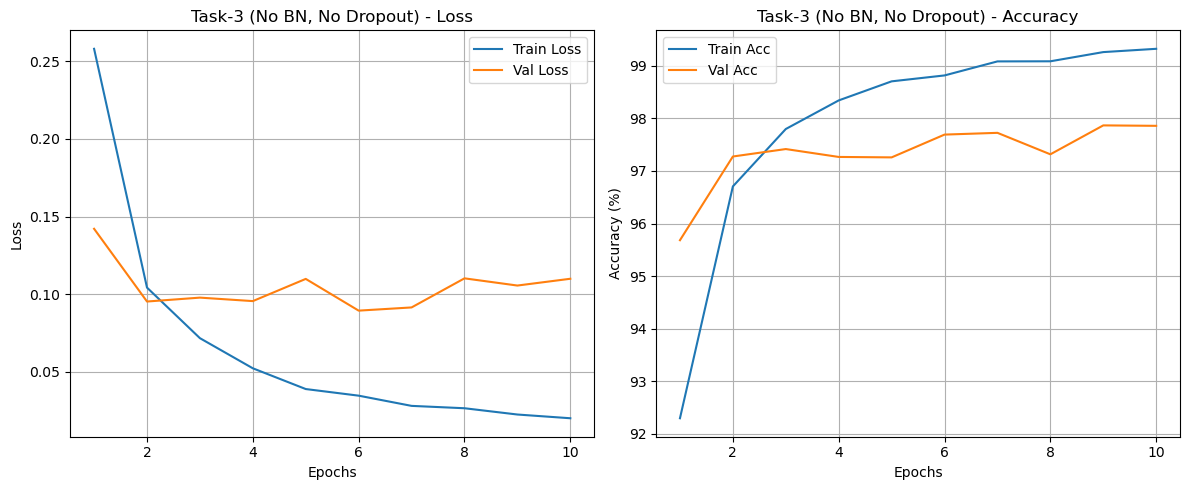


=== Task-3 | No BN, Dropout=0.1 ===


Epoch [1/10]: 100%|██████████| 750/750 [00:10<00:00, 74.60it/s, train_acc=91.8, train_loss=0.153] 


Epoch 1: Train Loss=0.2765, Train Acc=91.76% | Val Loss=0.1445, Val Acc=95.78%


Epoch [2/10]: 100%|██████████| 750/750 [00:10<00:00, 74.61it/s, train_acc=96.5, train_loss=0.0532]


Epoch 2: Train Loss=0.1156, Train Acc=96.49% | Val Loss=0.0976, Val Acc=97.17%


...

Epoch 8: Train Loss=0.0399, Train Acc=98.63% | Val Loss=0.0973, Val Acc=97.49%


Epoch [9/10]: 100%|██████████| 750/750 [00:10<00:00, 73.87it/s, train_acc=98.9, train_loss=0.0404]  


Epoch 9: Train Loss=0.0351, Train Acc=98.85% | Val Loss=0.0906, Val Acc=97.92%


Epoch [10/10]: 100%|██████████| 750/750 [00:09<00:00, 75.92it/s, train_acc=98.9, train_loss=0.00399] 


Epoch 10: Train Loss=0.0334, Train Acc=98.92% | Val Loss=0.0885, Val Acc=98.13%


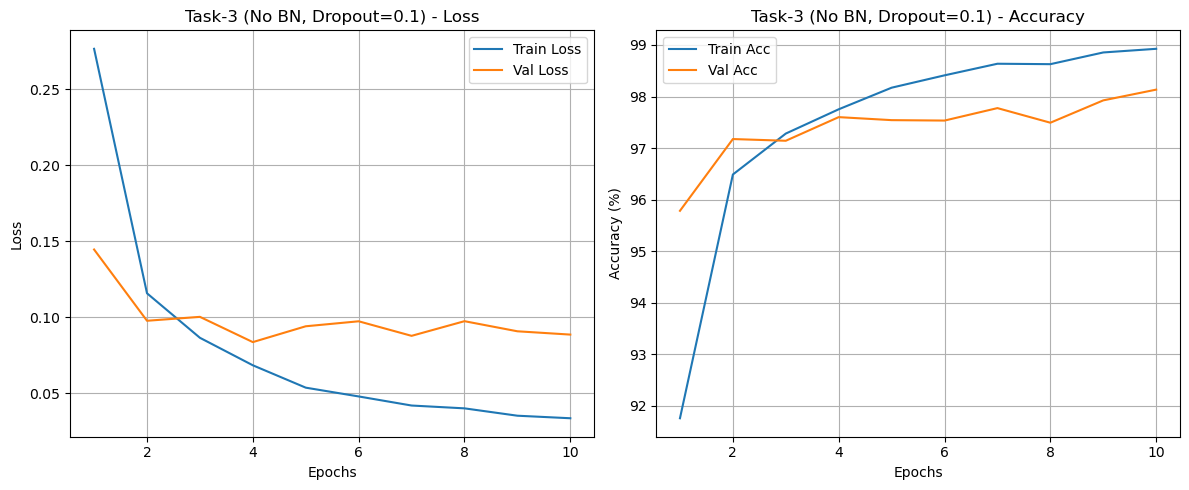


=== Task-3 | BN + Dropout=0.25 ===


Epoch [1/10]: 100%|██████████| 750/750 [00:10<00:00, 73.36it/s, train_acc=91.3, train_loss=0.213] 


Epoch 1: Train Loss=0.3119, Train Acc=91.31% | Val Loss=0.1212, Val Acc=96.46%


Epoch [2/10]: 100%|██████████| 750/750 [00:10<00:00, 73.74it/s, train_acc=95.5, train_loss=0.291] 


Epoch 2: Train Loss=0.1502, Train Acc=95.45% | Val Loss=0.0943, Val Acc=97.19%


...

Epoch 8: Train Loss=0.0640, Train Acc=97.98% | Val Loss=0.0675, Val Acc=98.15%


Epoch [9/10]: 100%|██████████| 750/750 [00:10<00:00, 73.56it/s, train_acc=98, train_loss=0.0132]   


Epoch 9: Train Loss=0.0606, Train Acc=98.01% | Val Loss=0.0613, Val Acc=98.22%


Epoch [10/10]: 100%|██████████| 750/750 [00:10<00:00, 73.46it/s, train_acc=98.1, train_loss=0.0223] 


Epoch 10: Train Loss=0.0546, Train Acc=98.15% | Val Loss=0.0604, Val Acc=98.09%


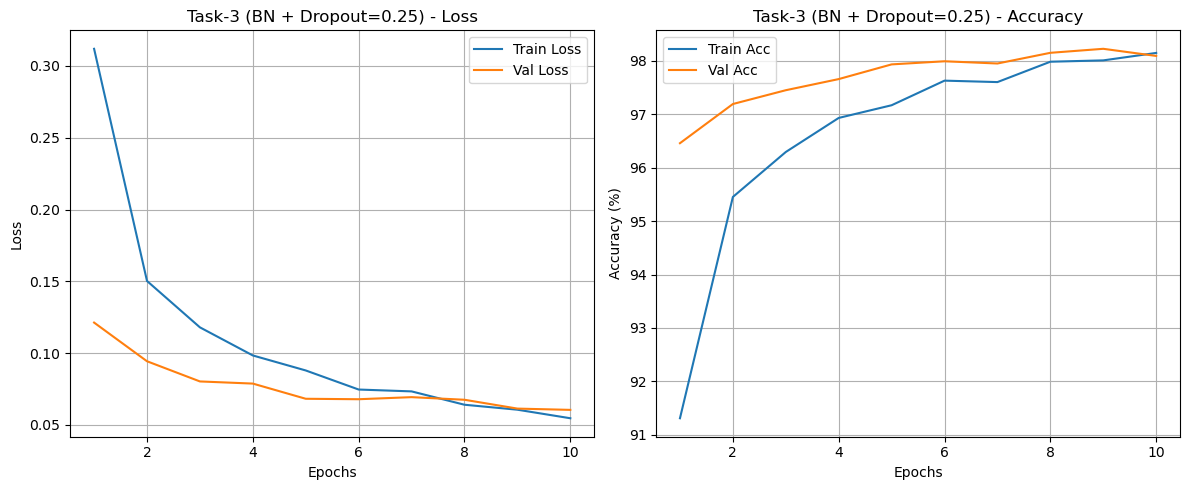

In [36]:
task3_results = {}

configs = {
    "No BN, No Dropout": (False, 0.0),
    "No BN, Dropout=0.1": (False, 0.1),
    "BN + Dropout=0.25": (True, 0.25)
}

for name, (bn, drop) in configs.items():
    print(f"\n=== Task-3 | {name} ===")

    model = FlexibleMLP(
        activation='relu',
        use_bn=bn,
        dropout=drop
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    tl, vl, ta, va = train_with_metrics(
        model, optimizer, criterion,
        train_loader, val_loader,
        epochs=10,
        device=device
    )

    task3_results[name] = (tl, vl, ta, va)

    plot_task_curves(tl, vl, ta, va,
                     title_prefix=f"Task-3 ({name})")


### Task 3: Effect of Batch Normalization and Dropout – Tabular Summary

| Experiment | Batch Normalization | Dropout Rate | Training Accuracy | Testing Accuracy | Loss Curve Stability | Overfitting | Key Observation |
|-----------|---------------------|--------------|-------------------|------------------|----------------------|-------------|-----------------|
| 1 | No | 0.0 | High | Low | Unstable | High | Model overfits due to lack of regularization |
| 2 | No | 0.1 | Moderate–High | Moderate | Slightly Stable | Medium | Dropout reduces overfitting but training remains unstable |
| 3 | Yes | 0.25 | Moderate | High | Very Stable | Low | Best generalization with stable and fast convergence |
